# Desarrollo de modelos

En esta seccion se desarrollaran los modelos de prediccion para la investigacion. Al tener un problema de clasificacion, se trabajaran los siguientes modelos adicionales al modelo original. Estos modelos de clasificacion son los siguientes: 

 - KNN → KD-Trees, Ball Trees, FAISS.
 - Ridge/Lasso → Solver optimizado saga.
 - Naive Bayes → partial_fit() para entrenamiento por lotes.
 - XGBoost → tree_method='hist' y early_stopping_rounds.
 - SVM → SGD SVM (SGDClassifier) , LinearSVC en vez de SVC(kernel='linear'), RBF con Random Fourier Features

En las siguientes lineas de codigo, se encontrara el desarrollo de los modelos.

In [9]:
import pandas as pd
df = pd.read_csv("metricas_camiones.csv")
df

,Unnamed: 0,Equipo,Suspension,Falla,mean_presion,sd_presion,max_presion,min_presion,peaks_presion,median_presion,pressure_change_rate,high_duration_presion,cv_presion,num_trend_changes
0,0,022-740,L,1,21641.506274,5260.175821,34473.8,1631.8,379,21790.10,2585.327605,30.874722,0.243060,4101
1,1,022-740,R,0,19801.161056,5206.772627,49117.1,2005.2,120,20042.30,2664.393305,26.602222,0.262953,4119
2,2,022-826,L,0,26095.888559,5403.453187,42847.2,3305.6,1290,26346.10,2305.921631,185.937778,0.207061,3429
3,3,022-826,R,1,17643.687250,5294.362156,38931.1,2166.7,92,17444.50,2437.081836,11.661389,0.300071,3247
4,4,022-830,L,0,20735.948609,8770.715037,42379.4,0.0,232,22112.20,2552.602642,13.269722,0.422971,1116
5,5,022-830,R,1,20362.288119,7051.834262,41785.6,572.2,173,20813.90,2943.257877,66.706111,0.346318,1143
6,6,022-832,L,1,26049.137374,5469.099930,44803.9,3952.2,2598,25959.20,2615.794375,341.459167,0.209953,6800
7,7,022-832,R,1,19161.502664,5473.768538,39605.6,1970.6,279,19073.05,2668.015273,34.658889,0.285665,6733
8,8,022-833,L,0,25824.587161,5795.656571,43979.4,1314.4,1305,26006.70,2230.039001,280.631389,0.224424,3329
9,9,022-833,R,1,17070.491458,5589.978325,36353.5,1295.6,87,16836.10,2378.520038,11.404444,0.327464,3218


Cargamos los datos Pre-procesados para el desarrollo de los modelos.

### Modelo KNN

En las siguientes lineas de codigos, aplicaremos los modelos KD-Trees, Ball Trees Y FAISS.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
from sklearn.neighbors import KNeighborsClassifier

X = df.drop(columns=["Equipo", "Suspension", "Falla"])
y = df["Falla"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11],  # Número de vecinos
    "kneighborsclassifier__weights": ["uniform", "distance"],  # Pesos de los vecinos
    "kneighborsclassifier__metric": ["euclidean", "manhattan", "minkowski"],  # Distancias
    "kneighborsclassifier__algorithm": ["ball_tree", "kd_tree"]  # Algoritmos de búsqueda
}

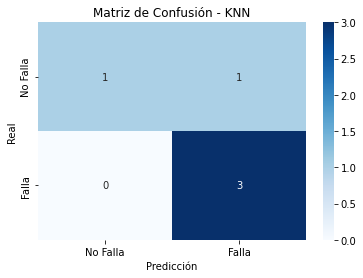

Best cross-validation score: 0.68
Mejor combinación de hiperparámetros: {'kneighborsclassifier__algorithm': 'ball_tree', 'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}
Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



In [29]:
# 6️⃣ Realizar búsqueda de hiperparámetros con GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

# 7️⃣ Evaluar el mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 🔹 Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# 🔹 Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - KNN")
plt.show()

# 🔹 Métricas adicionales
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print(f"Mejor combinación de hiperparámetros: {grid_search.best_params_}")
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))



### Modelo L1/L2 Penalty Logistic Regression 

### Modelo Random Forest 

### Modelo XGBoost

### Modelo SVM (Support Vector Machines)

### Modelo ANN (Redes Neuronales Artificiales)